Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


344/344 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.5277 - loss: 0.9373 - val_accuracy: 0.6644 - val_loss: 0.7705
Epoch 2/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.7565 - loss: 0.5928 - val_accuracy: 0.6742 - val_loss: 0.7903
Epoch 3/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8797 - loss: 0.3301 - val_accuracy: 0.6509 - val_loss: 0.9448
Epoch 4/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9360 - loss: 0.1804 - val_accuracy: 0.6393 - val_loss: 1.1650
Epoch 5/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9599 - loss: 0.1176 - val_accuracy: 0.6307 - val_loss: 1.4228
Epoch 1/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 51s 140ms/step - accuracy: 0.5902 - loss: 0.8640 - val_accuracy: 0.6869 - val_loss: 0.7108
Epoch 2/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 81s 139ms/step - accuracy: 0.7558 - loss: 0.5976 - val_accuracy: 0.7129 - val_loss: 0.6794
Epoch 3/5
344/344 ━━━━━━━━━━━━━━━━━━━━ 46s 134ms/step - accuracy: 0.8077 - loss: 0.4902 - val_accuracy: 0

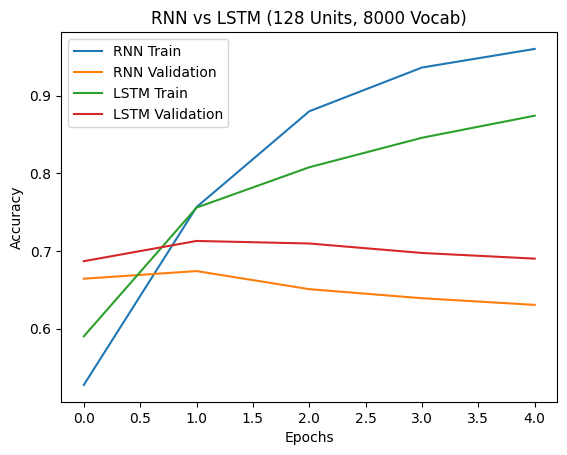

In [ ]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Embedding
from tensorflow.keras.utils import to_categorical

# ===============================
# 2. LOAD DATASET
# ===============================
df = pd.read_csv('/content/Tweets.csv')

texts = df['text'].astype(str)
labels = df['sentiment']

# ===============================
# 3. ENCODE LABELS
# ===============================
le = LabelEncoder()
labels = le.fit_transform(labels)
labels = to_categorical(labels)

# ===============================
# 4. TOKENIZATION (8000 WORDS)
# ===============================
max_words = 8000   # <-- updated
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_len)

y = labels

# ===============================
# 5. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6. RNN MODEL (128 UNITS)
# ===============================
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    SimpleRNN(128, activation='tanh'),   # <-- updated
    Dense(64, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ===============================
# 7. TRAIN RNN
# ===============================
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ===============================
# 8. LSTM MODEL (128 UNITS)
# ===============================
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    LSTM(128),   # <-- updated
    Dense(64, activation='relu'),
    Dense(y.shape[1], activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ===============================
# 9. TRAIN LSTM
# ===============================
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

# ===============================
# 10. COMPARISON GRAPH
# ===============================
plt.figure()

# RNN
plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation')

# LSTM
plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('RNN vs LSTM (128 Units, 8000 Vocab)')
plt.legend()

plt.show()

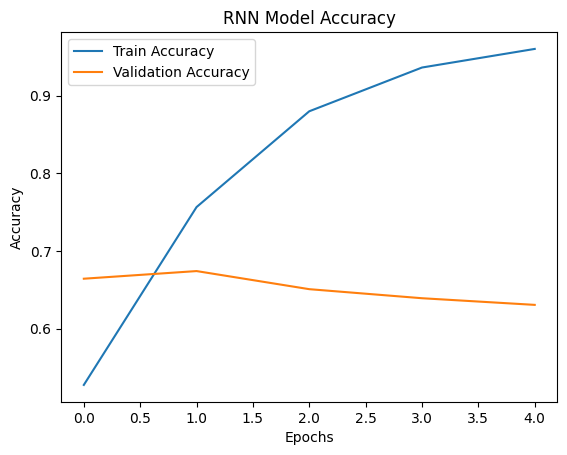

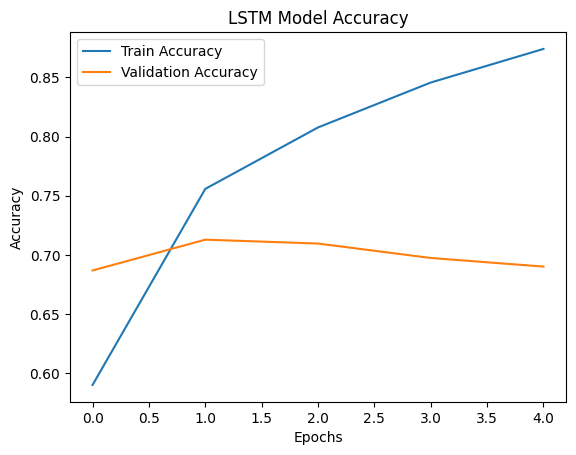

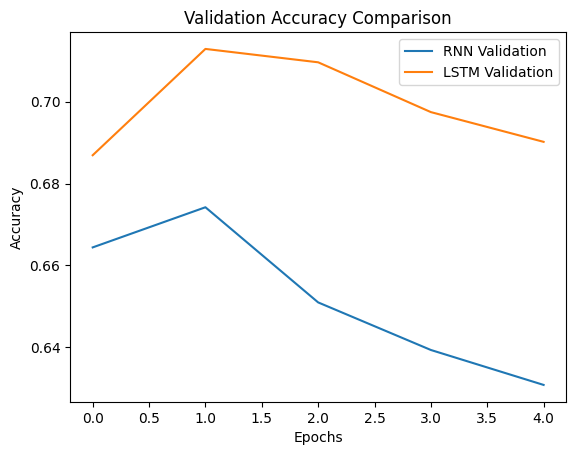

Final RNN Validation Accuracy: 0.6307076811790466
Final LSTM Validation Accuracy: 0.6901946663856506
✅ LSTM is performing better.


In [ ]:
# ===============================
# 10. RNN GRAPH
# ===============================
plt.figure()
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('RNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# ===============================
# 11. LSTM GRAPH
# ===============================
plt.figure()
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# ===============================
# 12. COMPARISON GRAPH
# ===============================
plt.figure()

plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


# ===============================
# 13. FINAL RESULT
# ===============================
rnn_final = history_rnn.history['val_accuracy'][-1]
lstm_final = history_lstm.history['val_accuracy'][-1]

print("Final RNN Validation Accuracy:", rnn_final)
print("Final LSTM Validation Accuracy:", lstm_final)

if lstm_final > rnn_final:
    print("✅ LSTM is performing better.")
else:
    print("✅ RNN is performing better.")